## 03 - Explainability with SHAP

This notebook demonstrates SHAP explainability on a tree-based model (XGBoost) using the **real IEEE-CIS** training data and a saved model from `models/`.

### What SHAP is (high level)

- **SHAP values** decompose a prediction into feature contributions.
- The **summary bar plot** shows which features matter most *on average*.
- The **beeswarm plot** shows distribution of SHAP values per feature across samples.
- A **force plot** explains one individual prediction as a push/pull from the baseline.

### Global importance: SHAP summary bar plot

This ranks features by mean absolute SHAP value (overall impact).

Training XGBoost...
Model saved!


SHAP computed!


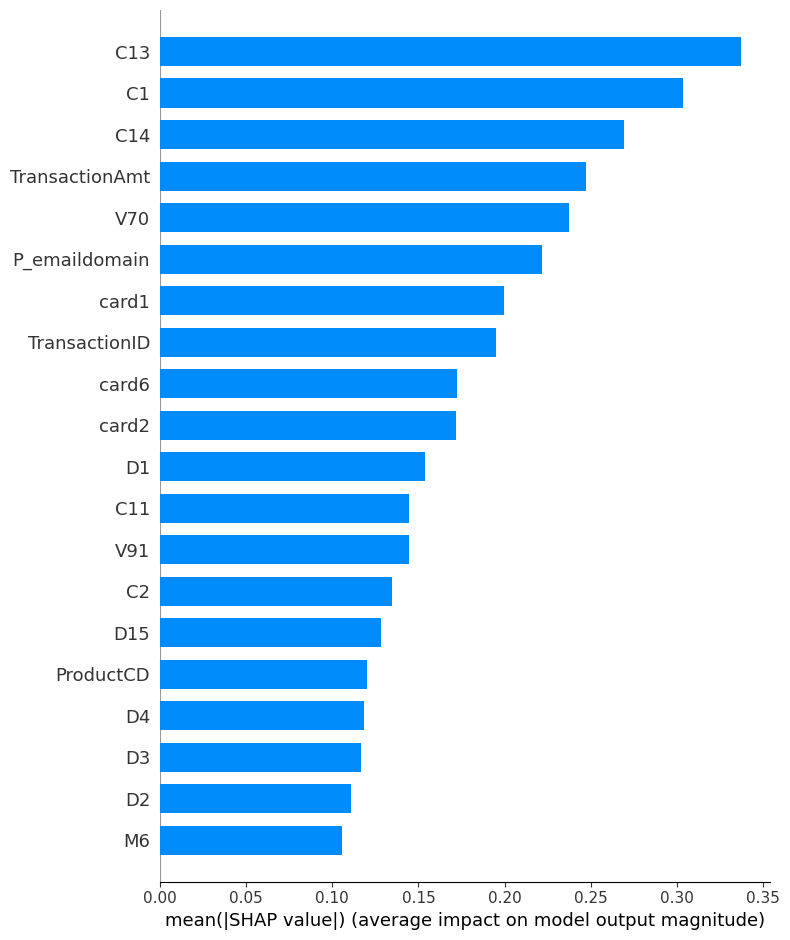

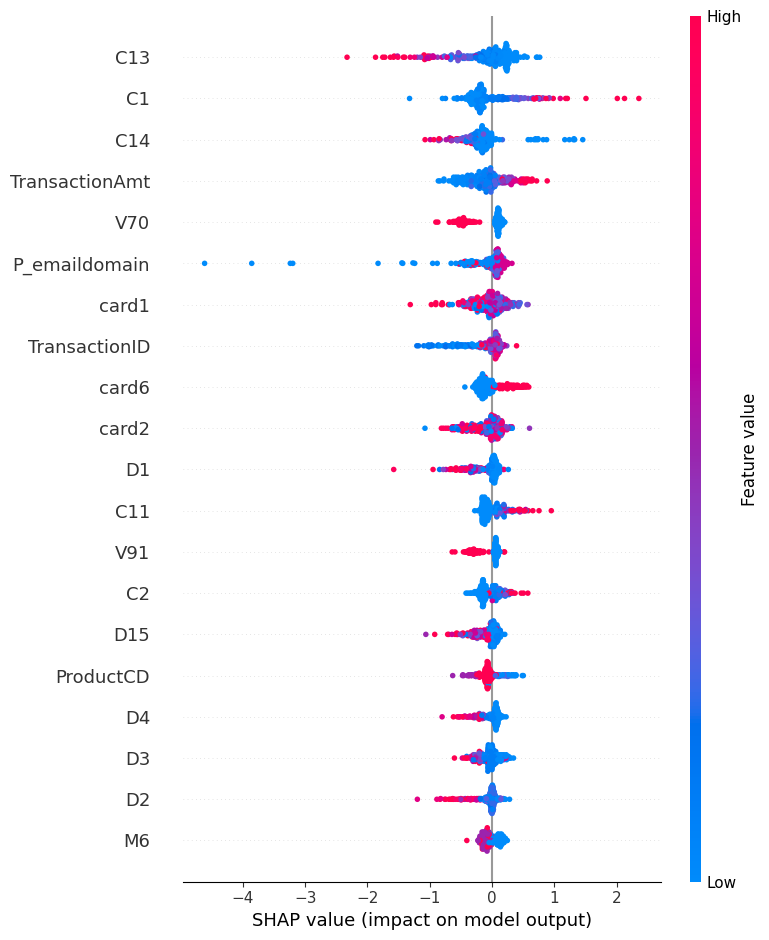

All SHAP plots saved!


In [4]:
import sys
sys.path.insert(0, "D:/mlops4/fraud-mlops")
import os, glob, joblib, shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from src.data_utils import load_data, handle_missing_values, get_feature_target_split

# Load real data
df = load_data(
    "D:/mlops4/fraud-mlops/data/raw/train_transaction.csv",
    "D:/mlops4/fraud-mlops/data/raw/train_identity.csv"
)
df = handle_missing_values(df)
X, y = get_feature_target_split(df)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Train XGBoost
print("Training XGBoost...")
xgb_model = XGBClassifier(n_estimators=100, max_depth=6,
                           scale_pos_weight=50, random_state=42,
                           eval_metric='logloss', n_jobs=-1)
xgb_model.fit(X_train, y_train)

# Save model
os.makedirs("D:/mlops4/fraud-mlops/models", exist_ok=True)
joblib.dump(xgb_model, "D:/mlops4/fraud-mlops/models/xgboost_model.joblib")
print("Model saved!")

# SHAP
os.makedirs("D:/mlops4/fraud-mlops/reports", exist_ok=True)
shap.initjs()
explainer = shap.TreeExplainer(xgb_model)
X_explain = X_test.sample(300, random_state=42)
shap_values = explainer.shap_values(X_explain)
print("SHAP computed!")

# Plot 1 - Global bar
shap.summary_plot(shap_values, X_explain, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("D:/mlops4/fraud-mlops/reports/shap_global.png", dpi=150)
plt.show()

# Plot 2 - Beeswarm
shap.summary_plot(shap_values, X_explain, show=False)
plt.tight_layout()
plt.savefig("D:/mlops4/fraud-mlops/reports/shap_beeswarm.png", dpi=150)
plt.show()

print("All SHAP plots saved!")

### Individual explanations: SHAP force plots

Below we show 3 individual *fraud* predictions (or the top-3 highest probabilities if there are fewer).

In [5]:
probs = model.predict_proba(X_test.values)[:, 1]
idx_sorted = np.argsort(-probs)

top_idx = idx_sorted[:3]
for i, idx in enumerate(top_idx, start=1):
    x_row = X_test.iloc[idx]
    sv = explainer.shap_values(pd.DataFrame([x_row]))
    print(f"Example {i}: p(fraud)={probs[idx]:.4f}")
    display(shap.force_plot(explainer.expected_value, sv[0], x_row))

Example 1: p(fraud)=0.9953


Example 2: p(fraud)=0.9947


Example 3: p(fraud)=0.9944


In [6]:
import os
os.makedirs("D:/mlops4/fraud-mlops/models", exist_ok=True)
joblib.dump(xgb_model, "D:/mlops4/fraud-mlops/models/xgboost_model.joblib")
print("Saved!")
print("Files in models:", os.listdir("D:/mlops4/fraud-mlops/models"))

Saved!
Files in models: ['xgboost_model.joblib']
